In [1]:
import healpy as hp
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import sys, sysconfig, platform
tf.keras.backend.clear_session() #clear any previous models

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data/"
os.chdir(data_directory)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1' #disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  #suppress TF warnings
print("Current working directory:", os.getcwd())

print(sys.executable)
print(platform.python_version())

2025-10-15 19:08:29.808461: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-15 19:08:36.577316: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-15 19:08:39.964419: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2025-10-15 19:08:39.964450: I 

Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data
/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/conda_envs/sky_nn_env/bin/python
3.10.15


In [2]:
import tensorflow as tf, sys, os
print("TF:", tf.__version__)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))

TF: 2.10.1
Python: 3.10.15
LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64


Filename: ./simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
NSIDE: 256


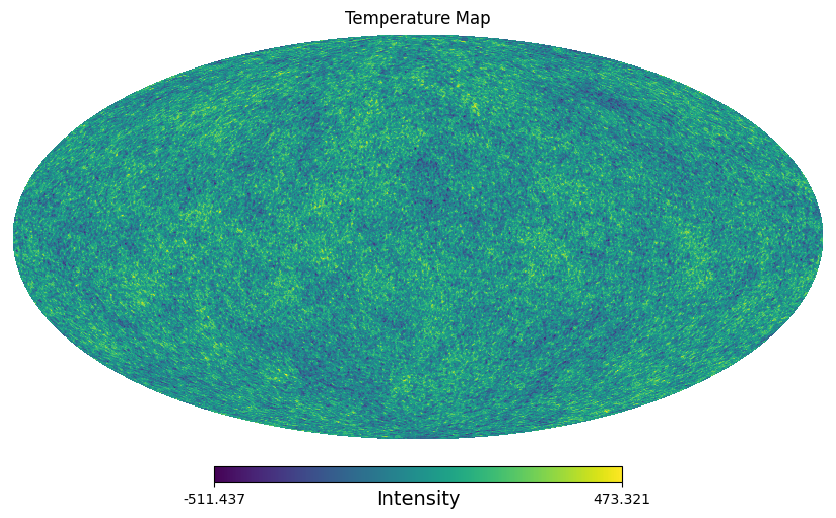

In [3]:
from SkyNeuralNets import read_map
#Read the data
path_lcdm = "./simulated_maps/"
map_temp_data = read_map(path_lcdm + 'cmb_map_0.fits')

#Visualize the map
nside = hp.npix2nside(len(map_temp_data))
#nside = 64
print(f"NSIDE: {nside}")

#Plot
hp.mollview(map_temp_data, title="Temperature Map", unit="Intensity")
plt.show()

In [11]:
def read_all_maps(path_feature, n_maps=10):
    maps = []
    labels = []
    
    #Feature maps
    for i in range(n_maps):
        map_feature = read_map(f"{path_feature}cmb_map_feature_{i}.fits")
        maps.append(map_feature)
        labels.append(1)  #feature
    
    maps = np.array(maps).astype(np.float32)[..., None]  #Add channel dimension
    labels = np.array(labels).astype(np.int32)
    #print(labels)
    return maps, labels

In [12]:
def map_to_image(hp_map, xsize=256):
    #Validate that map has correct length
    hp_map = np.asarray(hp_map, dtype=np.float64)
    try:
        nside = hp.get_nside(hp_map)
    except Exception as e:
        print("Invalid map shape:", hp_map.shape)
        raise e
    img = hp.cartview(hp_map, xsize=xsize, return_projected_map=True, title="", cbar=False)
    plt.close()
    return img

In [13]:
path_smallfeature = "./simulated_maps/"
path_bigfeature = "./simulated_maps/Ae1/"
x_raw_smallF, y_rawsmallF = read_all_maps(path_smallfeature, n_maps=5) #0: lcdm, 1:feature
x_raw_bigF, y_rawbigF = read_all_maps(path_bigfeature, n_maps=5) #0: lcdm, 1:feature

Filename: ./simulated_maps/cmb_map_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   


ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_feature_1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_feature_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_feature_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_feature_4.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 Primary

In [14]:
x_small_new = np.array(x_raw_smallF).squeeze()
x_big_new = np.array(x_raw_bigF).squeeze()

In [15]:
imgs_small = np.array([map_to_image(m) for m in x_small_new])
if imgs_small.ndim == 3:
    imgs_small = imgs_small[..., np.newaxis]  #add channel dimension

imgs_big = np.array([map_to_image(m) for m in x_big_new])
if imgs_big.ndim == 3:
    imgs_big = imgs_big[..., np.newaxis]  #add channel dimension

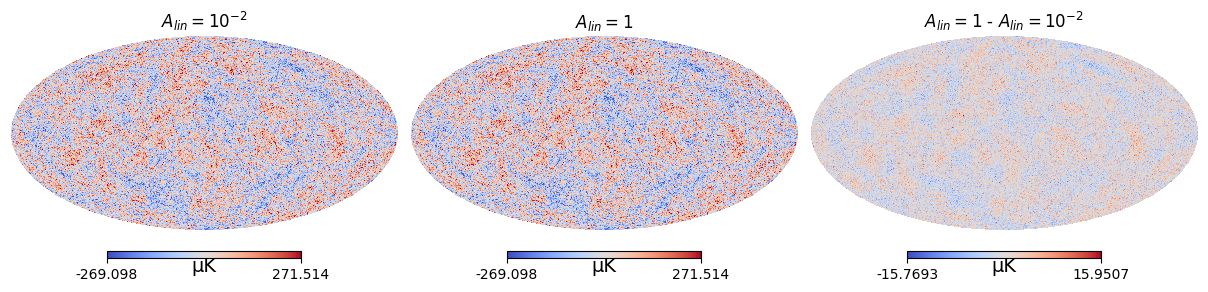

In [24]:
from SkyNeuralNets import compare_maps_spherical, compare_maps_patches
compare_maps_spherical(x_small_new[0], x_big_new[0], titleA="$A_{lin}=10^{-2}$", titleB="$A_{lin}=1$", lon_center=0, lat_center=0)
#plt.savefig("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/comparison_maps.png", dpi=300)

/home/csic/eoy/ioj/.local/lib/python3.10/site-packages/functions/data_preprocessing.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


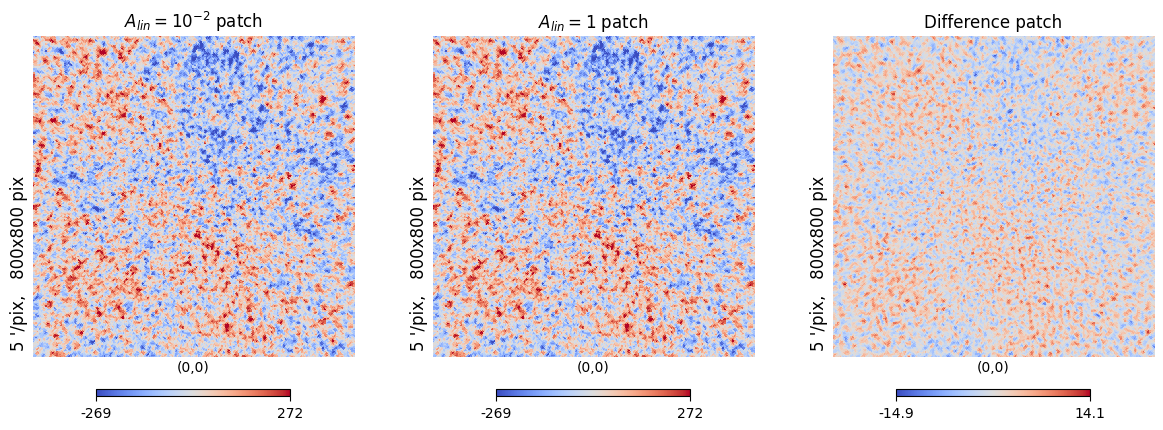

In [26]:
compare_maps_patches(x_small_new[0], x_big_new[0], titleA="$A_{lin}=10^{-2}$", titleB="$A_{lin}=1$", lon_center=0, lat_center=0)
#plt.savefig("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/comparison_patches.png", dpi=300)

In [27]:
from sklearn.model_selection import train_test_split
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(imgs_small, y_rawsmallF, test_size=0.2, random_state=15)
X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(imgs_big, y_rawbigF, test_size=0.2, random_state=15)

In [36]:
def z_score_n(X_train, X_test):

    """Compute μ,σ on TRAIN ONLY; apply to all splits. Returns scaled arrays + (μ,σ)."""
    mu  = X_train.mean(dtype=np.float64)
    std = X_train.std(dtype=np.float64)
    # avoid divide-by-zero
    std = std if std > 0 else 1.0

    def _scale(Z): return ((Z - mu) / std).astype(np.float32)
    return _scale(X_train), _scale(X_test),  (float(mu), float(std))

In [37]:
X_train_small, X_test_small, (mu, std) = z_score_n(X_train_small, X_test_small)
X_train_big, X_test_big, (mu, std) = z_score_n(X_train_big, X_test_big)

In [45]:
hp.mollview(X_train_small[0], title="Raw small-feature CMB map", unit="μK")

TypeError: bad number of pixels